# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [73]:
df = pd.read_csv("Projeto 3 Supermercado Final.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

Categorias com média acima da mediana:
                    Categoria        Media  Mediana    Diferenca
0  belleza-y-cuidado-personal  1783.556485   1569.0   214.556485
2                  congelados  2108.042553   1519.0   589.042553
3                      frutas  1724.473684   1195.0   529.473684
4        instantaneos-y-sopas   765.491228    439.0   326.491228
5                     lacteos  2385.219239    989.0  1396.219239
6                    verduras  1343.296875   1180.0   163.296875

Categorias com média abaixo da mediana:
            Categoria        Media  Mediana   Diferenca
1  comidas-preparadas  3095.043478   3290.0 -194.956522


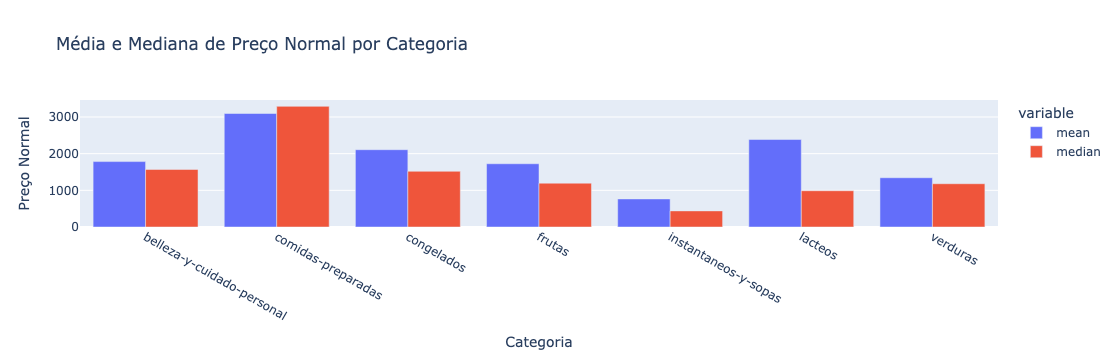

In [187]:
estatisticas_categoria = df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median']).reset_index()

estatisticas_categoria['Diferenca'] = estatisticas_categoria['mean'] - estatisticas_categoria['median']

categorias_media_acima = estatisticas_categoria[estatisticas_categoria['Diferenca'] > 0]
categorias_media_acima = categorias_media_acima[['Categoria', 'mean', 'median', 'Diferenca']]
categorias_media_acima.columns = ['Categoria', 'Media', 'Mediana','Diferenca']

categorias_media_abaixo = estatisticas_categoria[estatisticas_categoria['Diferenca'] < 0]
categorias_media_abaixo = categorias_media_abaixo[['Categoria', 'mean', 'median','Diferenca']]
categorias_media_abaixo.columns = ['Categoria', 'Media', 'Mediana','Diferenca']


print("Categorias com média acima da mediana:")
print(categorias_media_acima)
print("\nCategorias com média abaixo da mediana:")
print(categorias_media_abaixo)

fig = px.bar(estatisticas_categoria, 
             x='Categoria', 
             y=['mean', 'median'],
             title='Média e Mediana de Preço Normal por Categoria',
             labels={'value': 'Preço Normal', 'Categoria': 'Categoria'},
             barmode='group')
fig.show()

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [84]:
categorias_top = desvio_categoria.head(10)['Categoria']
df_top = df[df['Categoria'].isin(categorias_top)]
comportamento = df_top.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median', 'std']).reset_index()
comportamento.columns = ['Categoria', 'Media', 'Mediana', 'Desvio_Padrao']
comportamento_ordenado = comportamento.sort_values(by='Desvio_Padrao', ascending=False)
comportamento_ordenado

,Categoria,Media,Mediana,Desvio_Padrao
5,lacteos,2385.219239,989.0,3925.816164
0,belleza-y-cuidado-personal,1783.556485,1569.0,2210.041719
2,congelados,2108.042553,1519.0,2111.539896
1,comidas-preparadas,3095.043478,3290.0,2019.911428
3,frutas,1724.473684,1195.0,1639.151114
4,instantaneos-y-sopas,765.491228,439.0,1170.232869
6,verduras,1343.296875,1180.0,1012.699625


Digite nesse campo o comportamento que você identificou.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

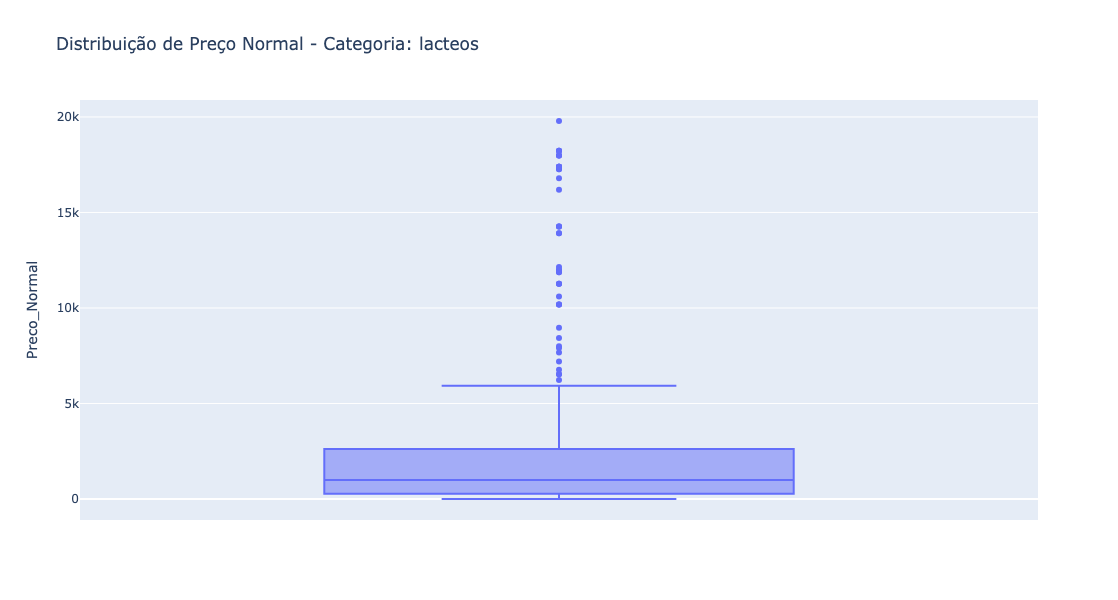

In [133]:
categoria_maior_desvio = desvio_categoria.iloc[0]['Categoria']

df_categoria = df[df['Categoria'] == categoria_maior_desvio]

fig = px.box(data_frame=df_categoria, y='Preco_Normal',
             title=f'Distribuição de Preço Normal - Categoria: {categoria_maior_desvio}')
fig.update_layout(
    width=1000,
    height=600
)

fig.show()

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

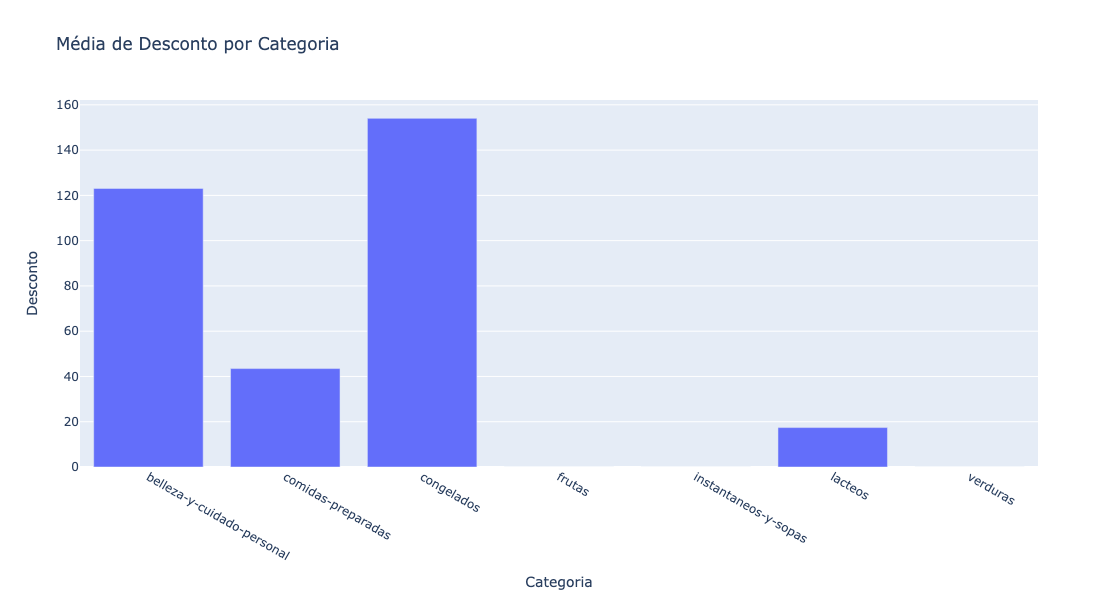

In [131]:
media_desconto = df.groupby('Categoria')['Desconto'].mean().reset_index()

fig = px.bar(media_desconto, x='Categoria', y='Desconto', title='Média de Desconto por Categoria')
fig.update_layout(
    width=1000, 
    height=600 
)

fig.show()


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

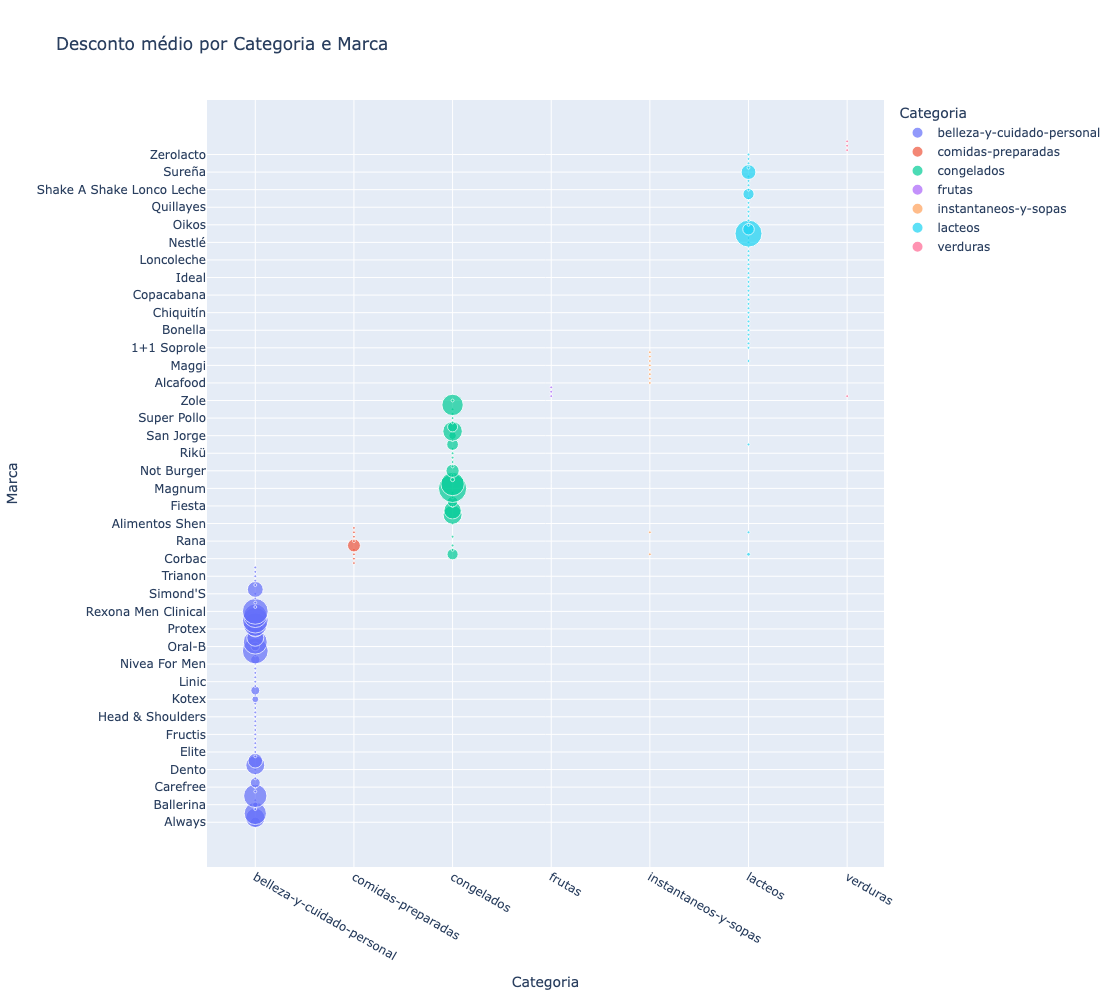

In [127]:
fig = px.scatter(df_bolhas,
                 x='Categoria',
                 y='Marca',
                 size='Desconto',
                 color='Categoria',
                 hover_name='Marca',
                 title='Desconto médio por Categoria e Marca',
                 size_max=20)
min_size = 10 

df_bolhas['size'] = df_bolhas['Desconto'].apply(lambda x: max(x, min_size))
fig = px.scatter(df_bolhas,
                 x='Categoria',
                 y='Marca',
                 size='size',
                 color='Categoria',
                 hover_name='Marca',
                 title='Desconto médio por Categoria e Marca',
                 size_max=20)
fig.update_layout(
    width=1000,
    height=1000
)

fig.show()